In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load stock price data
stock_symbol = 'AAPL'
stock_df = pd.read_csv(f'../data/raw/{stock_symbol}.csv')

print(f"Loaded {stock_symbol} data with shape: {stock_df.shape}")
print("\nFirst 5 rows:")
print(stock_df.head())
print("\nColumn names:")
print(stock_df.columns.tolist())

Loaded AAPL data with shape: (3774, 6)

First 5 rows:
         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800

Column names:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [3]:
# Data preparation
# Convert Date column
if 'Date' in stock_df.columns:
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    stock_df.set_index('Date', inplace=True)
elif 'date' in stock_df.columns:
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    stock_df.set_index('date', inplace=True)

# Ensure we have Adj Close
if 'Adj Close' not in stock_df.columns and 'Close' in stock_df.columns:
    stock_df['Adj Close'] = stock_df['Close']

# Calculate daily returns
stock_df['Daily_Return'] = stock_df['Adj Close'].pct_change() * 100

# Check for missing values
print("Missing values before cleaning:")
print(stock_df.isnull().sum())

# Drop NaN values
stock_df = stock_df.dropna()
print(f"\nData after cleaning: {len(stock_df)} rows")
print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")

Missing values before cleaning:
Close           0
High            0
Low             0
Open            0
Volume          0
Adj Close       0
Daily_Return    1
dtype: int64

Data after cleaning: 3773 rows
Date range: 2009-01-05 00:00:00 to 2023-12-29 00:00:00


In [4]:
#Moving Averages (Manual implementation - no TA-Lib needed)
# Simple Moving Averages
stock_df['SMA_10'] = stock_df['Adj Close'].rolling(window=10).mean()
stock_df['SMA_20'] = stock_df['Adj Close'].rolling(window=20).mean()
stock_df['SMA_50'] = stock_df['Adj Close'].rolling(window=50).mean()
stock_df['SMA_200'] = stock_df['Adj Close'].rolling(window=200).mean()

# Exponential Moving Averages
stock_df['EMA_12'] = stock_df['Adj Close'].ewm(span=12, adjust=False).mean()
stock_df['EMA_26'] = stock_df['Adj Close'].ewm(span=26, adjust=False).mean()
stock_df['EMA_50'] = stock_df['Adj Close'].ewm(span=50, adjust=False).mean()

print("Moving Averages calculated")
print(f"Current SMA_20: ${stock_df['SMA_20'].iloc[-1]:.2f}")
print(f"Current EMA_50: ${stock_df['EMA_50'].iloc[-1]:.2f}")

Moving Averages calculated
Current SMA_20: $192.49
Current EMA_50: $187.11


In [5]:
# RSI (Relative Strength Index)
def calculate_rsi(data, window=14):
    """Calculate RSI indicator manually"""
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stock_df['RSI_14'] = calculate_rsi(stock_df['Adj Close'], 14)

print("RSI calculated")
print(f"Current RSI: {stock_df['RSI_14'].iloc[-1]:.2f}")
print(f"RSI range: {stock_df['RSI_14'].min():.2f} to {stock_df['RSI_14'].max():.2f}")

RSI calculated
Current RSI: 40.19
RSI range: 3.18 to 97.49


In [6]:
# MACD (Moving Average Convergence Divergence)
def calculate_macd(data, fast=12, slow=26, signal=9):
    """Calculate MACD manually"""
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

stock_df['MACD'], stock_df['MACD_Signal'], stock_df['MACD_Hist'] = calculate_macd(stock_df['Adj Close'])

print("MACD calculated")

MACD calculated


In [7]:
# Additional Indicators
# Bollinger Bands
def calculate_bollinger_bands(data, window=20, num_std=2):
    sma = data.rolling(window=window).mean()
    std = data.rolling(window=window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    return upper_band, sma, lower_band

stock_df['BB_Upper'], stock_df['BB_Middle'], stock_df['BB_Lower'] = calculate_bollinger_bands(stock_df['Adj Close'])

# Volume indicators
stock_df['Volume_SMA'] = stock_df['Volume'].rolling(window=20).mean()
stock_df['Volume_Ratio'] = stock_df['Volume'] / stock_df['Volume_SMA']

# Volatility
stock_df['Volatility_20d'] = stock_df['Daily_Return'].rolling(window=20).std()

print("Additional indicators calculated")

Additional indicators calculated


In [8]:
# Generate Trading Signals
# Buy signals (oversold + volume confirmation)
stock_df['Buy_Signal'] = (
    (stock_df['RSI_14'] < 30) & 
    (stock_df['Volume_Ratio'] > 1.2) & 
    (stock_df['Adj Close'] < stock_df['BB_Lower'])
).astype(int)

# Sell signals (overbought + MACD confirmation)
stock_df['Sell_Signal'] = (
    (stock_df['RSI_14'] > 70) & 
    (stock_df['MACD'] < stock_df['MACD_Signal']) &
    (stock_df['Adj Close'] > stock_df['BB_Upper'])
).astype(int)

print(f"Total Buy signals: {stock_df['Buy_Signal'].sum()}")
print(f"Total Sell signals: {stock_df['Sell_Signal'].sum()}")

Total Buy signals: 55
Total Sell signals: 5


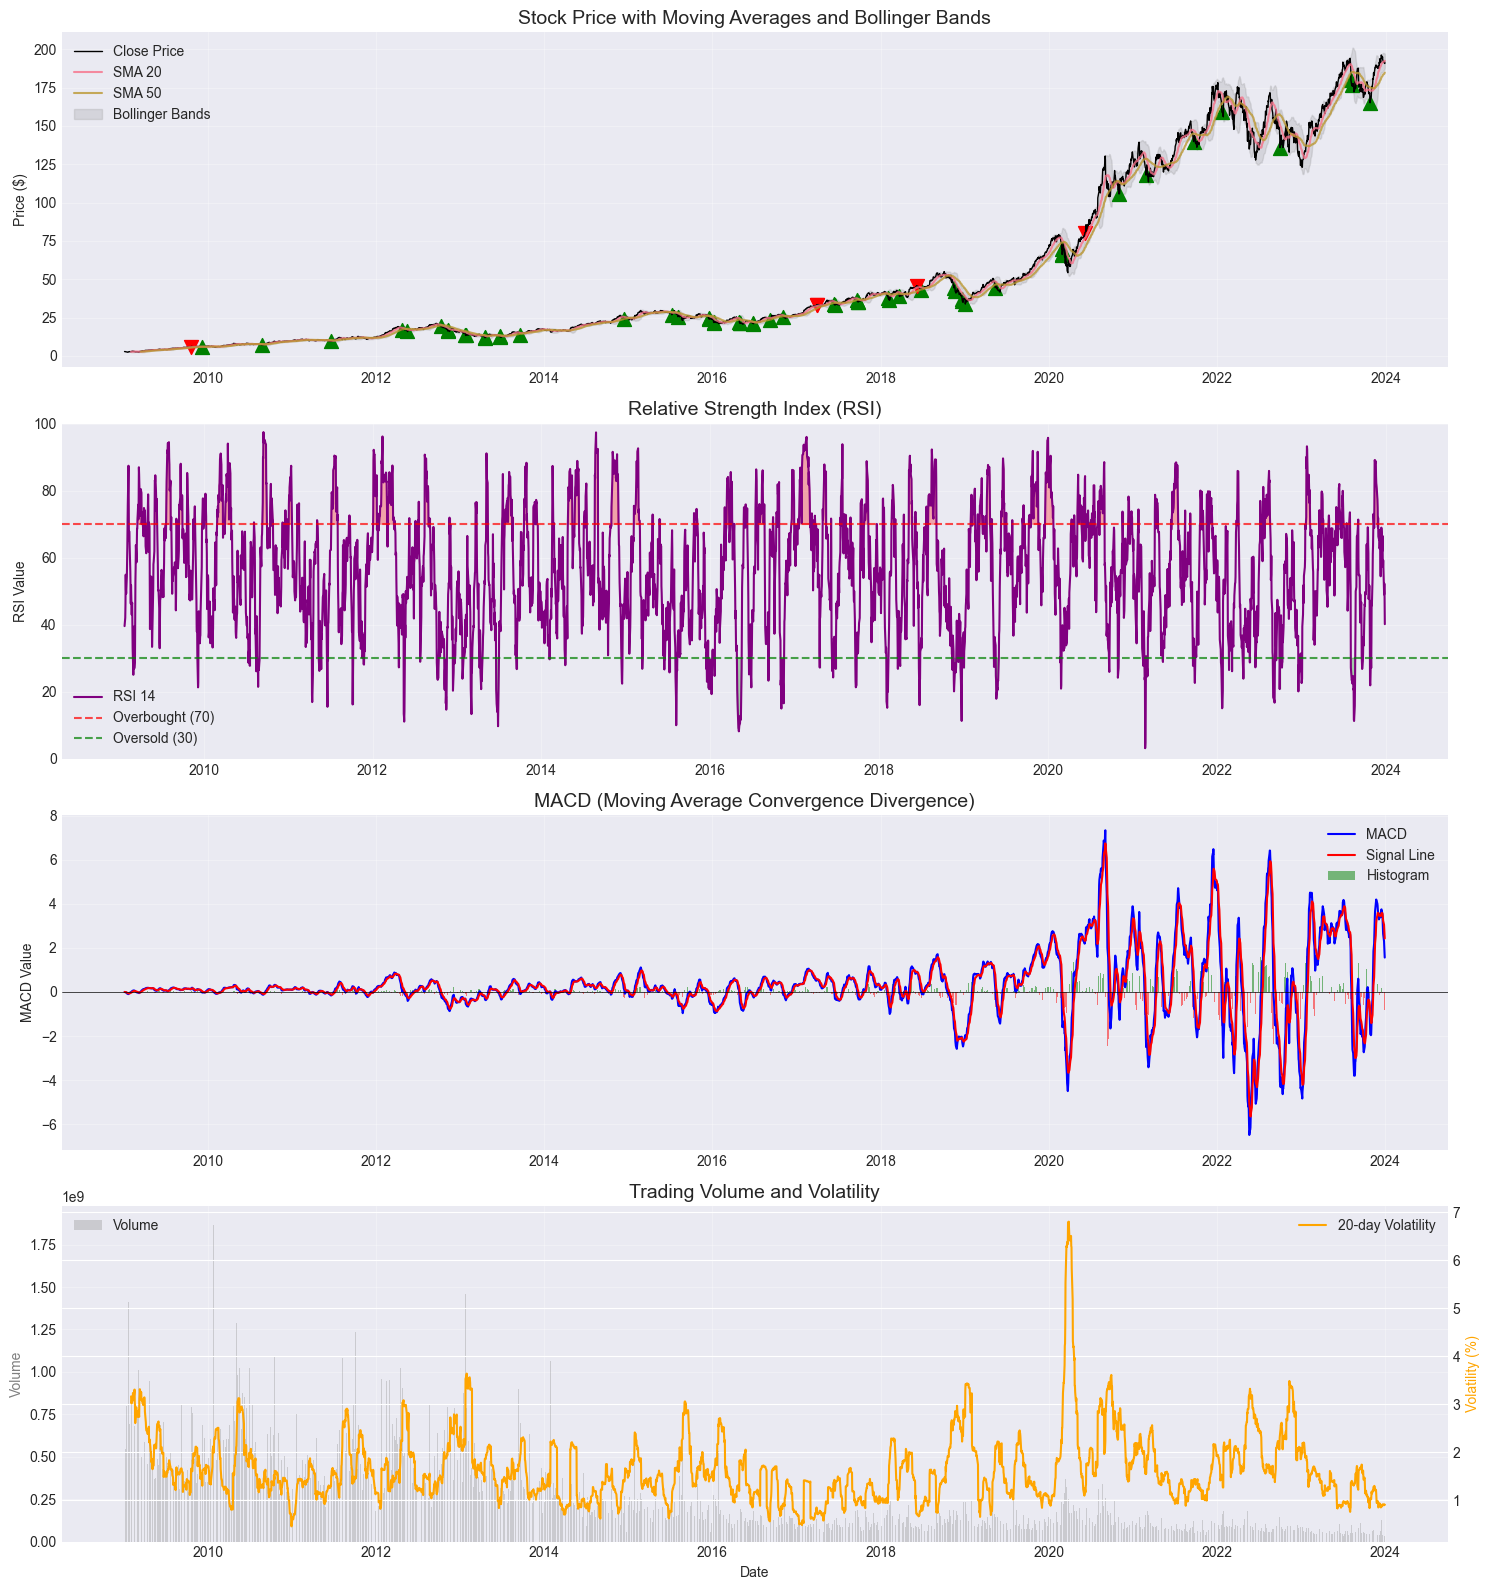

In [9]:
# Visualization - Price with Moving Averages
fig, axes = plt.subplots(4, 1, figsize=(15, 16))

# Plot 1: Price with Moving Averages
axes[0].plot(stock_df.index, stock_df['Adj Close'], label='Close Price', linewidth=1, color='black')
axes[0].plot(stock_df.index, stock_df['SMA_20'], label='SMA 20', linewidth=1.5, alpha=0.8)
axes[0].plot(stock_df.index, stock_df['SMA_50'], label='SMA 50', linewidth=1.5, alpha=0.8)
axes[0].fill_between(stock_df.index, stock_df['BB_Lower'], stock_df['BB_Upper'], alpha=0.2, label='Bollinger Bands', color='gray')
axes[0].set_title('Stock Price with Moving Averages and Bollinger Bands', fontsize=14)
axes[0].set_ylabel('Price ($)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Mark buy/sell signals
buy_dates = stock_df[stock_df['Buy_Signal'] == 1].index
sell_dates = stock_df[stock_df['Sell_Signal'] == 1].index
axes[0].scatter(buy_dates, stock_df.loc[buy_dates, 'Adj Close'], color='green', marker='^', s=100, label='Buy Signal')
axes[0].scatter(sell_dates, stock_df.loc[sell_dates, 'Adj Close'], color='red', marker='v', s=100, label='Sell Signal')

# Plot 2: RSI
axes[1].plot(stock_df.index, stock_df['RSI_14'], label='RSI 14', color='purple', linewidth=1.5)
axes[1].axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(stock_df.index, 70, stock_df['RSI_14'], where=(stock_df['RSI_14'] > 70), alpha=0.3, color='red')
axes[1].fill_between(stock_df.index, 30, stock_df['RSI_14'], where=(stock_df['RSI_14'] < 30), alpha=0.3, color='green')
axes[1].set_title('Relative Strength Index (RSI)', fontsize=14)
axes[1].set_ylabel('RSI Value')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: MACD
axes[2].plot(stock_df.index, stock_df['MACD'], label='MACD', color='blue', linewidth=1.5)
axes[2].plot(stock_df.index, stock_df['MACD_Signal'], label='Signal Line', color='red', linewidth=1.5)
colors = ['green' if val >= 0 else 'red' for val in stock_df['MACD_Hist']]
axes[2].bar(stock_df.index, stock_df['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('MACD (Moving Average Convergence Divergence)', fontsize=14)
axes[2].set_ylabel('MACD Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Volume and Volatility
ax4_twin = axes[3].twinx()
axes[3].bar(stock_df.index, stock_df['Volume'], alpha=0.3, label='Volume', color='gray')
axes[3].set_ylabel('Volume', color='gray')
ax4_twin.plot(stock_df.index, stock_df['Volatility_20d'], label='20-day Volatility', color='orange', linewidth=1.5)
ax4_twin.set_ylabel('Volatility (%)', color='orange')
axes[3].set_title('Trading Volume and Volatility', fontsize=14)
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left')
ax4_twin.legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

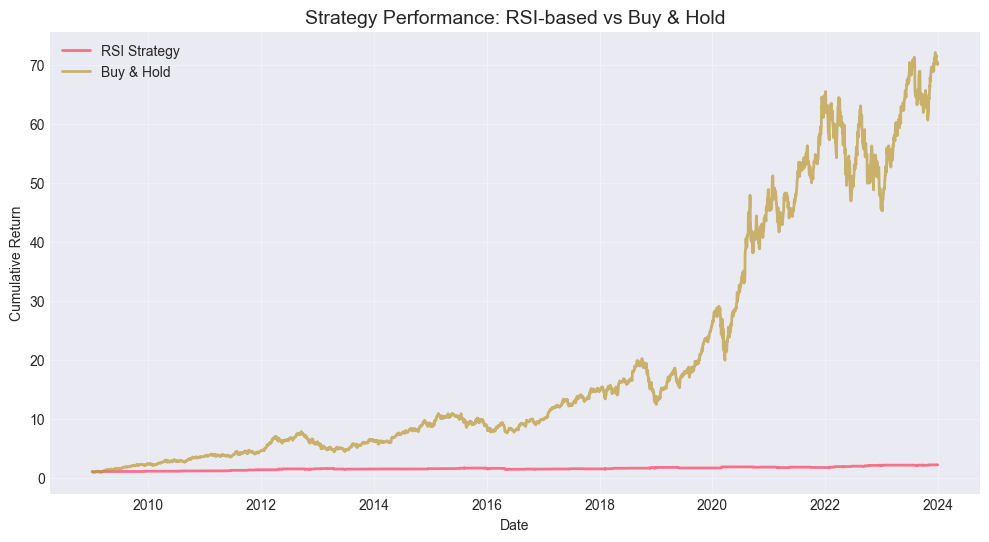

Strategy Final Return: 117.37%
Buy & Hold Return: 6907.74%


In [10]:
# Strategy Backtest
# Simple strategy: Buy when RSI < 30, sell when RSI > 70
stock_df['Position'] = 0
stock_df.loc[stock_df['RSI_14'] < 30, 'Position'] = 1
stock_df.loc[stock_df['RSI_14'] > 70, 'Position'] = 0

stock_df['Strategy_Return'] = stock_df['Daily_Return'] * stock_df['Position'].shift(1)
stock_df['Cumulative_Strategy'] = (1 + stock_df['Strategy_Return']/100).cumprod()
stock_df['Cumulative_BuyHold'] = (1 + stock_df['Daily_Return']/100).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(stock_df.index, stock_df['Cumulative_Strategy'], label='RSI Strategy', linewidth=2)
plt.plot(stock_df.index, stock_df['Cumulative_BuyHold'], label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('Strategy Performance: RSI-based vs Buy & Hold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Strategy Final Return: {(stock_df['Cumulative_Strategy'].iloc[-1] - 1) * 100:.2f}%")
print(f"Buy & Hold Return: {(stock_df['Cumulative_BuyHold'].iloc[-1] - 1) * 100:.2f}%")

In [11]:
# Summary
print("\n" + "="*50)
print("TECHNICAL INDICATORS SUMMARY")
print("="*50)
print(f"Period Analyzed: {stock_df.index.min()} to {stock_df.index.max()}")
print(f"Average Daily Return: {stock_df['Daily_Return'].mean():.3f}%")
print(f"Daily Volatility: {stock_df['Daily_Return'].std():.3f}%")
print(f"Average RSI: {stock_df['RSI_14'].mean():.2f}")
print(f"Current Market Condition: ", end="")
if stock_df['RSI_14'].iloc[-1] > 70:
    print("Overbought - Consider Selling")
elif stock_df['RSI_14'].iloc[-1] < 30:
    print("Oversold - Consider Buying")
else:
    print("Neutral")


TECHNICAL INDICATORS SUMMARY
Period Analyzed: 2009-01-05 00:00:00 to 2023-12-29 00:00:00
Average Daily Return: 0.129%
Daily Volatility: 1.801%
Average RSI: 56.51
Current Market Condition: Neutral
